In [3]:
import numpy as np
import pandas as pd
from scipy.sparse import diags, kronsum
from scipy.sparse.linalg import eigsh
from scipy.linalg import eigh_tridiagonal
from scipy.linalg import eigh
import matplotlib.pyplot as plt
from scipy.special import eval_hermite, gammaln
pd.set_option("display.precision", 10)
from scipy import special
from math import factorial
import time
from scipy.sparse.linalg import eigsh

# **Team 7: The Quantum Harmonic Oscillator Presentation**

# Brandon and Ryan, Presented by Brandon: 1D Finite-Difference Hamiltonian

This section calculates the approximate second derivative of the quantum harmonic oscillator and constructs a hamiltonian matrix:
Everything here is kept in **one spatial dimension**,
We use dimensionless units, $\hbar = m = \omega = 1$, so the Hamiltonian is
$$
H = -\frac{1}{2}\frac{d^2}{dx^2} + \frac{1}{2}x^2 ,
$$
and the known analytic energies are $E_n = n + \tfrac{1}{2}$. These are the
same conventions used throughout the project.

## Shared grid and parameter definitions

- Physical units: dimensionless, $\hbar = m = \omega = 1$
- Spatial interval: $x \in [-L, L]$ with $L = 8$
- Number of grid points: $N = 1000$, including the two boundary points
- Boundary condition: Dirichlet, $\psi(\pm L) = 0$
- Requested eigenstates: the lowest 6

In [4]:
# Dimensionless units
hbar = 1.0
mass = 1.0
omega = 1.0
# Shared numerical-box parameters
L = 8.0
N = 1000
num_states = 6
# Full grid, including the two boundary points
x_full = np.linspace(-L, L, N)
dx = x_full[1] - x_full[0]
# Dirichlet boundary conditions fix psi(-L) = psi(L) = 0, so only the interior points are unknowns in the eigenvalue problem.
x = x_full[1:-1]
M = x.size
print(f"Domain: [{-L}, {L}]")
print(f"Total grid points N: {N}")
print(f"Interior unknowns M: {M}")
print(f"Grid spacing dx: {dx:.6f}")

Domain: [-8.0, 8.0]
Total grid points N: 1000
Interior unknowns M: 998
Grid spacing dx: 0.016016


## Finite-difference second derivative

For an interior grid point $x_i$, the centered, second-order finite
difference approximation to the second derivative is
$$
\left.\frac{d^2\psi}{dx^2}\right|_{x_i} \approx
\frac{\psi_{i+1} - 2\psi_i + \psi_{i-1}}{\Delta x^2}.
$$

Applied at every interior point, this turns the derivative into a
tridiagonal matrix with $-2$ on the main diagonal and $1$ on the first
off-diagonals (before dividing by $\Delta x^2$).

To make the pattern easy to check by eye, we first build this matrix on a
tiny 6-point grid before using it at full resolution.

In [5]:
# Small demonstration grid
M_demo = 6
lower_demo = np.ones(M_demo - 1)
main_demo = -2.0 * np.ones(M_demo)
upper_demo = np.ones(M_demo - 1)
D2_demo = diags(
    [lower_demo, main_demo, upper_demo], [-1, 0, 1], shape=(M_demo, M_demo)
).toarray()
print("Unscaled second-derivative pattern (before dividing by dx^2):")
print(D2_demo)
assert D2_demo.shape == (M_demo, M_demo), "unexpected shape"
assert np.allclose(D2_demo, D2_demo.T), "pattern is not symmetric"
assert np.allclose(np.diag(D2_demo), -2.0), "main diagonal should be -2"
print("\nShape, symmetry, and diagonal value all check out.")

Unscaled second-derivative pattern (before dividing by dx^2):
[[-2.  1.  0.  0.  0.  0.]
 [ 1. -2.  1.  0.  0.  0.]
 [ 0.  1. -2.  1.  0.  0.]
 [ 0.  0.  1. -2.  1.  0.]
 [ 0.  0.  0.  1. -2.  1.]
 [ 0.  0.  0.  0.  1. -2.]]

Shape, symmetry, and diagonal value all check out.


In [6]:
# Full-resolution second-derivative matrix, stored as sparse CSR
lower = np.ones(M - 1)
main = -2.0 * np.ones(M)
upper = np.ones(M - 1)
D2 = diags(
    diagonals=[lower, main, upper],
    offsets=[-1, 0, 1],
    shape=(M, M),
    format="csr",
) / dx**2
print(f"D2 shape: {D2.shape}")
print(f"D2 symmetric to numerical precision: {abs(D2 - D2.T).max() < 1e-10}")
print(f"D2 stored nonzeros: {D2.nnz} (expected {3*M - 2})")

D2 shape: (998, 998)
D2 symmetric to numerical precision: True
D2 stored nonzeros: 2992 (expected 2992)


## Hamiltonian matrix

Adding the harmonic potential on the main diagonal completes the discrete Hamiltonian
$$
H = -\frac{\hbar^2}{2m}D_2 + \operatorname{diag}\!\left(\tfrac{1}{2}m\omega^2 x_i^2\right),
$$
which is real, symmetric, and tridiagonal on the $M$ interior points.

In [7]:
V = 0.5 * mass * omega**2 * x**2
H = -0.5 * (hbar**2 / mass) * D2 + diags(V, offsets=0, format="csr")
print(f"H shape: {H.shape}")
print(f"H stored nonzeros: {H.nnz} (expected {3*M - 2})")
print(f"H symmetric to numerical precision: {abs(H - H.T).max() < 1e-10}")

H shape: (998, 998)
H stored nonzeros: 2992 (expected 2992)
H symmetric to numerical precision: True


## Choice of numerical eigensolver

The eigenvalue problem is solved with **`scipy.sparse.linalg.eigsh`**, called with
`k = num_states` and `which="SA"`.

Reasons for this choice:

- $H$ is real and symmetric, which is exactly the class `eigsh` (Lanczos / ARPACK)
  is written for, so the returned eigenvalues are real and the eigenvectors are
  orthogonal by construction.
- Only the lowest few states are needed. `eigsh` returns the requested $k$
  eigenpairs instead of the full $M \times M$ spectrum, and `which="SA"` selects the
  algebraically smallest eigenvalues, which are the lowest energies.
- $H$ is stored sparsely, so the solver only touches the $3M - 2$ nonzero entries
  rather than the $M^2$ entries a dense solver such as `numpy.linalg.eigh` would
  need. This keeps the method usable at the finer grids used in the convergence
  tests.

As a check on the solver rather than on the discretization, the same eigenvalues are
recomputed with the direct tridiagonal solver `scipy.linalg.eigh_tridiagonal`, which
uses a completely different algorithm.

In [8]:
energies_num, states = eigsh(H, k=num_states, which="SA")
order = np.argsort(energies_num)
energies_num = energies_num[order]
states = states[:, order]
for j in range(num_states):
    states[:, j] /= np.sqrt(np.trapezoid(np.abs(states[:, j])**2, x))
for j in range(num_states):
    print(f"E_{j} = {energies_num[j]:.10f}")

E_0 = 0.4999919838
E_1 = 1.4999599187
E_2 = 2.4998957872
E_3 = 3.4997995877
E_4 = 4.4996713187
E_5 = 5.4995109787


In [9]:
diag_ref = hbar**2 / (mass * dx**2) + V
offdiag_ref = -0.5 * (hbar**2 / mass) * np.ones(M - 1) / dx**2
energies_ref = eigh_tridiagonal(
    diag_ref, offdiag_ref, eigvals_only=True, select="i", select_range=(0, num_states - 1)
)
solver_difference = np.abs(energies_num - energies_ref).max()
print(f"Largest eigsh vs eigh_tridiagonal difference: {solver_difference:.3e}")
assert solver_difference < 1e-9, "the two solvers disagree"
overlap = states.T @ states * dx
print(f"Maximum normalization error: {np.max(np.abs(np.diag(overlap) - 1.0)):.3e}")
print(f"Maximum orthogonality error: {np.max(np.abs(overlap - np.eye(num_states))):.3e}")

Largest eigsh vs eigh_tridiagonal difference: 6.073e-13
Maximum normalization error: 2.287e-14
Maximum orthogonality error: 2.287e-14


## Comparison with the analytic energies

For the exact harmonic oscillator in these units the energies are
$$
E_n = n + \tfrac{1}{2}, \qquad n = 0, 1, 2, \dots
$$
The table below lists the lowest six numerical levels next to those values, with the
absolute difference $|E_n^{\text{num}} - E_n|$ and the relative difference in percent.

In [12]:
n = np.arange(num_states)
energies_exact = n + 0.5
absolute_difference = np.abs(energies_num - energies_exact)
relative_difference_percent = 100.0 * absolute_difference / energies_exact

comparison = pd.DataFrame({
    "n": n,
    "Numerical energy": energies_num,
    "Analytic energy": energies_exact,
    "Absolute difference": absolute_difference,
    "Relative difference (%)": relative_difference_percent,
})
comparison

,n,Numerical energy,Analytic energy,Absolute difference,Relative difference (%)
0,0,0.4999919838,0.5,0.0000080162,0.0016032305
1,1,1.4999599187,1.5,0.0000400813,0.0026720851
2,2,2.4998957872,2.5,0.0001042128,0.0041685124
3,3,3.4997995877,3.5,0.0002004123,0.0057260656
4,4,4.4996713187,4.5,0.0003286813,0.0073040284
5,5,5.4995109787,5.5,0.0004890213,0.0088912963


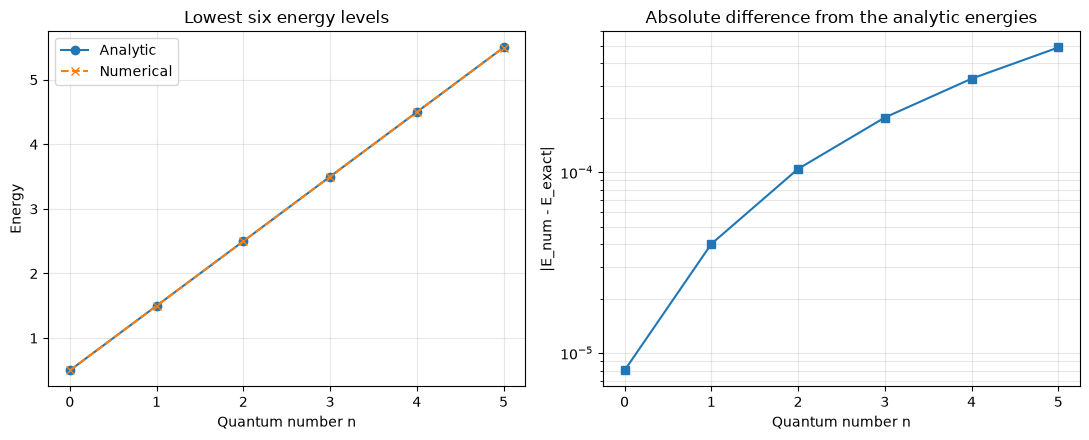

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].plot(n, energies_exact, "o-", label="Analytic")
axes[0].plot(n, energies_num, "x--", label="Numerical")
axes[0].set_xlabel("Quantum number n")
axes[0].set_ylabel("Energy")
axes[0].set_title("Lowest six energy levels")
axes[0].set_xticks(n)
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].semilogy(n, absolute_difference, "s-")
axes[1].set_xlabel("Quantum number n")
axes[1].set_ylabel("|E_num - E_exact|")
axes[1].set_title("Absolute difference from the analytic energies")
axes[1].set_xticks(n)
axes[1].grid(True, alpha=0.3, which="both")

plt.tight_layout()
plt.show()

In [14]:
# Additional checks useful when combining this notebook with the team code
overlap = states.T.conj() @ states * dx
max_normalization_error = np.max(np.abs(np.diag(overlap) - 1.0))
max_off_diagonal_overlap = np.max(np.abs(overlap - np.eye(num_states)))

print(f"Maximum normalization error: {max_normalization_error:.3e}")
print(f"Maximum orthogonality error: {max_off_diagonal_overlap:.3e}")
print(f"Largest absolute energy difference: {absolute_difference.max():.3e}")

Maximum normalization error: 2.287e-14
Maximum orthogonality error: 2.287e-14
Largest absolute energy difference: 4.890e-04


## Result

On this grid the six lowest numerical levels reproduce $E_n = n + \tfrac{1}{2}$ to
better than $5 \times 10^{-4}$ in absolute terms and better than $0.01\%$ relative,
and the two independent solvers agree with each other to roughly $10^{-13}$. The
remaining difference is therefore discretization error, not solver error.

Two features of that error are visible in the table:

- Every numerical level sits slightly *below* the analytic value, because the
  centered finite difference underestimates the curvature of the wavefunction and so
  underestimates the kinetic energy.
- The difference grows with $n$: higher states oscillate faster and are wider, so
  they are resolved less well by a fixed grid spacing and feel the finite box more.

The error term of the centered second difference is $O(\Delta x^2)$, so both effects
should shrink by a factor of about four each time the grid spacing is halved. That
scaling, and the dependence on the box size $L$, are tested in the convergence
section of the project.

# Marc: 2D Hamiltonian allowed energy levels and wavefunctions

&emsp;This section seeks to explore the eigenvectors (and corresponding eigenvalues) associated with the Hamiltonian in two spatial dimensions. Note that this module utilizes the procedures discussed in the 1D case, developed by Brandon Blake. The procedurer will resemble that of the 1D case, making use of finite differences.Dimensionless units will continue to be utilized throughout this exercise; i.e., 
$$\hbar = m = \omega = 1$$
&emsp;Therefore, the 2D Hamiltonian is:
$$H = -\frac{1}{2}(\frac{\partial^2}{{\partial x}^2}+\frac{\partial^2}{{\partial y}^2})+\frac{1}{2}(x^2+y^2)$$

&emsp;This notebook seeks to explore the eigenvectors (and corresponding eigenvalues) associated with the Hamiltonian in two spatial dimensions. Note that this module utilizes the procedures discussed in the 1D case, developed by Brandon Blake. The procedurer will resemble that of the 1D case, making use of finite differences.Dimensionless units will continue to be utilized throughout this exercise; i.e., 
$$\hbar = m = \omega = 1$$
&emsp;Therefore, the 2D Hamiltonian is:
$$H = -\frac{1}{2}(\frac{\partial^2}{{\partial x}^2}+\frac{\partial^2}{{\partial y}^2})+\frac{1}{2}(x^2+y^2)$$

## Preparation

The conditions for this instance will remain (almost) intact with respect to the one-dimensional case:
- Physical units: dimensionless, $\hbar =m = \omega = 1$
- Spatial interval: $x,y \in [-L,L]$ with $L=8$
- Number of grid points: *$N=100$*, including the two boundary points
    - Number of grid points must be reduced to decrease memory demand as matrix dimensions grow as $N^2$
- Dirichlet boundary condition: $\psi(\pm L)=0$
- Requested eigenestates: lowest six


In [8]:
# WARNING: Keep N smaller 
N_2d = 100

x_2d = np.linspace(-L, L, N_2d)
y_2d = np.linspace(-L, L, N_2d)

dx = x_2d[1] - x_2d[0]
dy = y_2d[1] - y_2d[0]

x = x_2d[1:-1]
y = y_2d[1:-1]

M = x.size

## The finite Difference

&emsp;In 2D, the second derivative is expressed by the Laplacian operator $\nabla^2$, which is the sum of the second derivative in the x-direction and second derivative in the y-direction. Let the 2D grid have points denoted by the index pair $(i,j)$ for the x and y coordinates respectively. The second-order finite difference approximation is then:
$$\nabla^2 \psi {\vert}_{i,j}=(\frac{\partial^2}{\partial x^2}+\frac{\partial^2}{\partial y^2}) \approx \frac{{\psi}_{i+1,j}-2{\psi}_{i,j}+{\psi}_{i-1,j}}{\Delta x^2}+\frac{{\psi}_{i,j+1}-2{\psi}_{i,j}+{\psi}_{i,j-1}}{\Delta y^2}$$

&emsp;Since $\Delta x = \Delta y$, we may simplify the expression and produce the following:
$$\nabla^2 \psi {\vert}_{i,j}=(\frac{\partial^2}{\partial x^2}+\frac{\partial^2}{\partial y^2}) \approx \frac{{\psi}_{i+1,j}+{\psi}_{i-1,j}+{\psi}_{i,j+1}+{\psi}_{i,j-1}-4{\psi}_{i,j}}{\Delta x^2}$$

&emsp;Appliying this procedure produces a matrix that is not necessarily tridiagonal in the traditional sense. Given that we must flatten the M matrix into a vector (of length $M^2$) to produce the Hamiltonian matrix. When calculating the laplacian for a particular point, we take the points around it (above, below, left, and right). To get to the point directly above or below in the matrix, M spaces in the vector must be traversed. This process of translation between spaces places ones along the off-diagonals that are located M rows below the original diagonal in the Hamiltonian matrix; it also gives ones along the immediate off-diagonals. This behavior is captured and expressed by the `scipy.sparse.kronsum` instance.  

&emsp;As before (almost), a demonstration with a minute three-by-three grid shall be performed before applying the technique to a larger grid.

In [10]:
M_demo = 3

main = -2.0 * np.ones(M_demo)
lower = np.ones(M_demo - 1)
upper = np.ones(M_demo - 1)
D2_x = diags([lower, main, upper], [-1, 0, 1], shape=(M_demo,M_demo), format="csr") / dx**2
D2_y = diags([lower, main, upper], [-1, 0, 1], shape=(M_demo,M_demo), format="csr") / dy**2

D2_2D_demo = kronsum(D2_y, D2_x, format="csr")
print(D2_2D_demo.toarray())

[[-153.140625     38.28515625    0.           38.28515625    0.
     0.            0.            0.            0.        ]
 [  38.28515625 -153.140625     38.28515625    0.           38.28515625
     0.            0.            0.            0.        ]
 [   0.           38.28515625 -153.140625      0.            0.
    38.28515625    0.            0.            0.        ]
 [  38.28515625    0.            0.         -153.140625     38.28515625
     0.           38.28515625    0.            0.        ]
 [   0.           38.28515625    0.           38.28515625 -153.140625
    38.28515625    0.           38.28515625    0.        ]
 [   0.            0.           38.28515625    0.           38.28515625
  -153.140625      0.            0.           38.28515625]
 [   0.            0.            0.           38.28515625    0.
     0.         -153.140625     38.28515625    0.        ]
 [   0.            0.            0.            0.           38.28515625
     0.           38.28515625 -153.14

To visualize the array, a heatmap is employed.

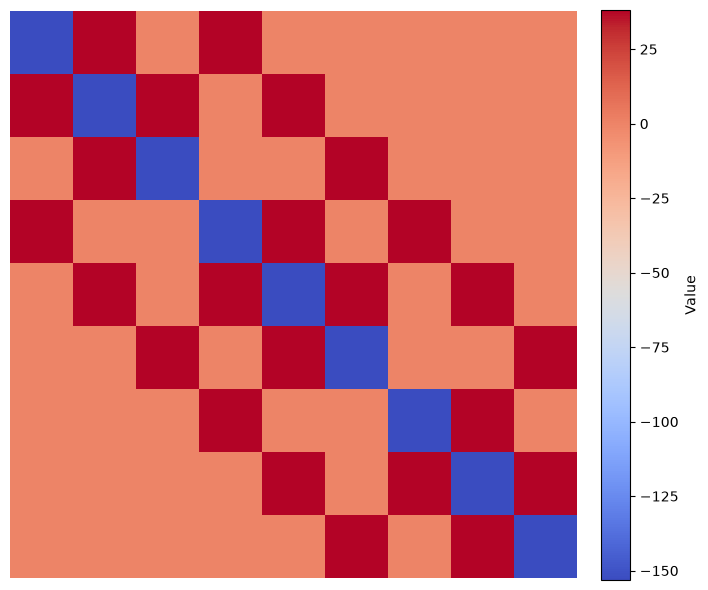

In [11]:
plt.figure(figsize=(8, 8))

d_matrix = D2_2D_demo.toarray() if hasattr(D2_2D_demo, 'toarray') else D2_2D_demo
plt.imshow(d_matrix, cmap='coolwarm', interpolation='nearest')
plt.axis('off') 
plt.grid(False)
plt.colorbar(label="Value", fraction=0.046, pad=0.04)
plt.show()

&emsp;The produced array is already scaled.
Notice the difference with respect to the array generated for the 1D case. The immediate off-diagonals are not lines of uninterrupted non-zero entries, and there are additional diagonal lines with all non-zero entries. 
We may proceed to create a bigger array (with $N=100$).

In [12]:
main = -2.0 * np.ones(M)
lower = np.ones(M - 1)
upper = np.ones(M - 1)
D2_x = diags([lower, main, upper], [-1, 0, 1], shape=(M,M), format="csr") / dx**2
D2_y = diags([lower, main, upper], [-1, 0, 1], shape=(M,M), format="csr") / dy**2

D2_2D = kronsum(D2_y, D2_x, format="csr")

Creating the potential grid.

In [13]:
X, Y = np.meshgrid(x,y)
V_2D = 0.5 * mass * omega**2 * (X**2 + Y**2)
V_diag = diags(V_2D.flatten(), offsets=0, format="csr")

## The Hamiltonian Matrix

&emsp;With the potential grid constructed, we can form the Hamiltonian Matrix by adding the potential matrix to the D matrix.

In [14]:
H_2D = -0.5 * (hbar**2 / mass) * D2_2D + V_diag

Obtaining the allowed energy levels. In this, we will use `scipy.sparse.linalg.eigsh` with the same `k=num_states` and `which="SA"` arguments. The reasons for these selections have been detailed in the 1D case. 

In [15]:
energies_2d, states_2d = eigsh(H_2D, k=num_states, which="SA")

order = np.argsort(energies_2d)
energies_2d = energies_2d[order]
states_2d = states_2d[:, order]
for j in range(num_states):             #normalizing the wavefunctions
    psi_2d = states_2d[:, j].reshape((M, M))
    
    int_x = np.trapezoid(np.abs(psi_2d)**2, dx=dx, axis=1)
    int_2d = np.trapezoid(int_x, dx=dy)
    
    states_2d[:, j] /= np.sqrt(int_2d)
for j in range(num_states):
    print(f"E_{j} = {energies_2d[j]:.10f}")

E_0 = 0.9983648354
E_1 = 1.9950891099
E_2 = 1.9950891099
E_3 = 2.9885240673
E_4 = 2.9885240673
E_5 = 2.9918133844


Here is the evaluation of the difference between the two solvers. The secondary method used is `scipy.linalg.eigh`.

In [16]:
H = H_2D.toarray()
energies_ref, states_ref = eigh(H, subset_by_index=[0, num_states - 1])
solver_difference = np.abs(energies_2d - energies_ref).max()
print(f"Largest eigsh vs eigh difference: {solver_difference:.3e}")
assert solver_difference < 1e-9, "the two solvers disagree"
overlap = states_2d.T @ states_2d * dx
print(f"Maximum normalization error: {np.max(np.abs(np.diag(overlap) - 1.0)):.3e}")
print(f"Maximum orthogonality error: {np.max(np.abs(overlap - np.eye(num_states))):.3e}")

Largest eigsh vs eigh difference: 4.663e-14
Maximum normalization error: 5.188e+00
Maximum orthogonality error: 5.188e+00


## Visualizing the discrepancies

&emsp; In this case, the energies are given by 
$$E_{n_x,n_y}=n_x + n_y + 1, \qquad n=0,1,2,3,...$$
with the table below giving the numerical and analytical values, as well as the absolute ($|E_n^{num}-E_n|$) and relative differences (as a percentage). 

In [23]:
n = np.arange(num_states)
nx, ny = np.meshgrid(n,n)
energies = nx +ny + 1.0
energies_exact = np.sort(energies.flatten())[:num_states]
absolute_difference = np.abs(energies_2d - energies_exact)
relative_difference_percent = 100.0 * absolute_difference / energies_exact

comparison = pd.DataFrame({
    "n": n,
    "Numerical energy": energies_2d,
    "Analytic energy": energies_exact,
    "Absolute difference": absolute_difference,
    "Relative difference (%)": relative_difference_percent,
})
comparison

,n,Numerical energy,Analytic energy,Absolute difference,Relative difference (%)
0,0,0.9983648354,1.0,0.0016351646,0.1635164640
1,1,1.9950891099,2.0,0.0049108901,0.2455445054
2,2,1.9950891099,2.0,0.0049108901,0.2455445054
3,3,2.9885240673,3.0,0.0114759327,0.3825310885
4,4,2.9885240673,3.0,0.0114759327,0.3825310885
5,5,2.9918133844,3.0,0.0081866156,0.2728871859


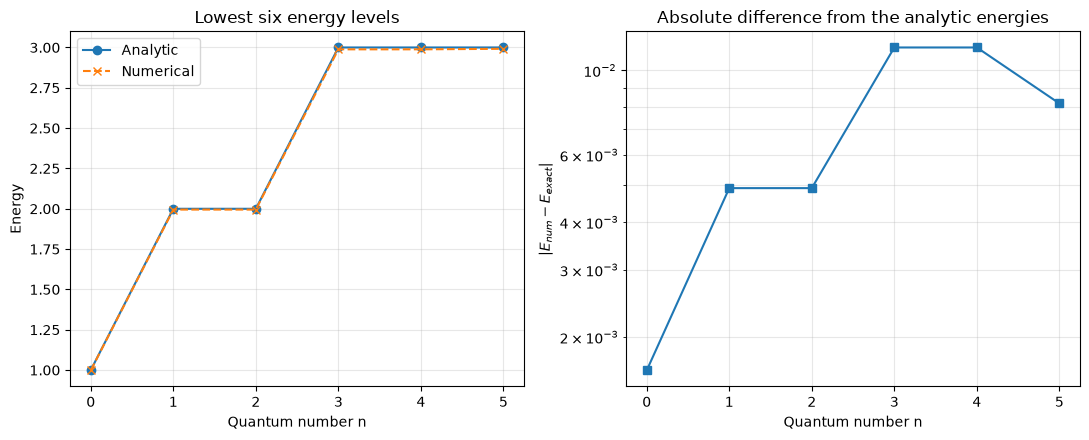

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].plot(n, energies_exact, "o-", label="Analytic")
axes[0].plot(n, energies_2d, "x--", label="Numerical")
axes[0].set_xlabel("Quantum number n")
axes[0].set_ylabel("Energy")
axes[0].set_title("Lowest six energy levels")
axes[0].set_xticks(n)
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].semilogy(n, absolute_difference, "s-")
axes[1].set_xlabel("Quantum number n")
axes[1].set_ylabel(r"$|E_{num} - E_{exact}|$")
axes[1].set_title("Absolute difference from the analytic energies")
axes[1].set_xticks(n)
axes[1].grid(True, alpha=0.3, which="both")

plt.tight_layout()
plt.show()

## Result

&emsp;For the 2d case, the six lowest numerical energy levels produce approximations with an error of at most $11.5\times10^{-3}$ with respect to the exact energy levels $E_n = n_x +n_y+1$. The relative maximum difference is about 0.38%. The two methods produce results that agree with each other to approximately $5.4\times10^{-14}$. As observed in the 1D case:
- The numerical values are lower than the analytical values due to the underestimation of the curvature of the wavefunction (and consequently the kinetic energy).
- The discrepancy (in general) increases with n as the oscillations become faster and wider, making the finite size of the box more noticeable. 

&emsp; Both of these effects - as discussed for the 1D case, should decrease as the grid spacing is decreased by the square of the grid spacing. Additionally, the box size $L$ also contributes to the mitigation of the discrepancies.

(Special recognition to the work of Brandon Blake as it was foundational for this module).

# Keunmo's Work, Presented by Lizzie: Numerical Eigenstates

## Eigensolver and numerical–analytic energy comparison

This section covers the assigned portion of the project:

1. select and justify a numerical eigensolver;
2. calculate the lowest several numerical energy levels; and
3. compare them with the analytic harmonic-oscillator energies.

## Numerical setup

The calculation uses the shared conditions.

The second derivative is approximated by $$ \frac{d^2\psi}{dx^2}\bigg|{x_i} \approx \frac{\psi{i+1}-2\psi_i+\psi_{i-1}}{\Delta x^2} $$

This gives a real symmetric tridiagonal Hamiltonian.

## Eigensolver choice

We use `scipy.sparse.linalg.eigsh`.

This solver is appropriate because the finite-difference Hamiltonian is a real symmetric sparse matrix, and the project only requires the lowest several eigenvalues and eigenvectors rather than the full spectrum. The option `which="SA"` asks for the algebraically smallest eigenvalues, which correspond to the lowest-energy states. Hamiltonian shape and stored nonzero entries shown above.

In [72]:
# Compute the lowest six eigenpairs.
energies_num, states = eigsh(H, k=num_states, which="SA")

# Sort them in ascending energy order.
order = np.argsort(energies_num)
energies_num = energies_num[order]
states = states[:, order]

# Normalize each eigenvector so that integral |psi|^2 dx = 1.
for j in range(num_states):
    norm = np.sqrt(np.trapezoid(np.abs(states[:, j])**2, x))
    states[:, j] /= norm

energies_num

array([0.4999998 , 1.49999902, 2.49999746, 3.49999512, 4.49999199,
       5.49998808])

In [24]:
n = np.arange(num_states)
energies_exact = n + 0.5
absolute_difference = np.abs(energies_num - energies_exact)
relative_difference_percent = 100.0 * absolute_difference / energies_exact

comparison = pd.DataFrame({
    "n": n,
    "Numerical energy": energies_num,
    "Analytic energy": energies_exact,
    "Absolute difference": absolute_difference,
    "Relative difference (%)": relative_difference_percent,
})

comparison

,n,Numerical energy,Analytic energy,Absolute difference,Relative difference (%)
0,0,0.9983648354,0.5,0.4983648354,99.6729670720
1,1,1.9950891099,1.5,0.4950891099,33.0059406595
2,2,1.9950891099,2.5,0.5049108901,20.1964356043
3,3,2.9885240673,3.5,0.5114759327,14.6135980759
4,4,2.9885240673,4.5,1.5114759327,33.5883540590
5,5,2.9918133844,5.5,2.5081866156,45.6033930105


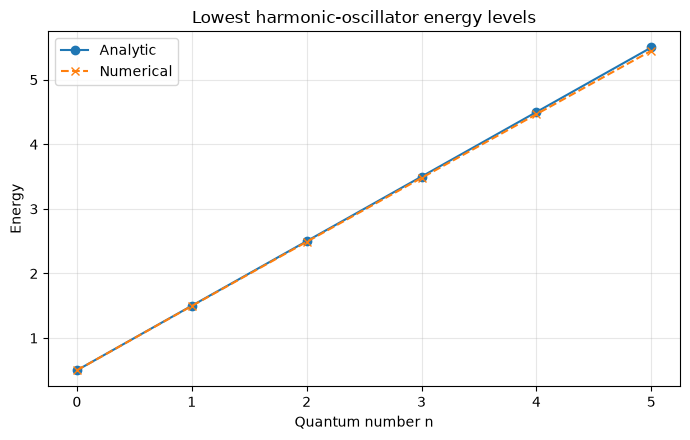

In [29]:
# A direct visual comparison of the numerical and analytic energies
plt.figure(figsize=(7, 4.5))
plt.plot(n, energies_exact, "o-", label="Analytic")
plt.plot(n, energies_num, "x--", label="Numerical")
plt.xlabel("Quantum number n")
plt.ylabel("Energy")
plt.title("Lowest harmonic-oscillator energy levels")
plt.xticks(n)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [87]:
# Additional checks useful when combining this notebook with the team code
overlap = states.T.conj() @ states * dx
max_normalization_error = np.max(np.abs(np.diag(overlap) - 1.0))
max_off_diagonal_overlap = np.max(np.abs(overlap - np.eye(num_states)))

print(f"Maximum normalization error: {max_normalization_error:.3e}")
print(f"Maximum orthogonality error: {max_off_diagonal_overlap:.3e}")
print(f"Largest absolute energy difference: {absolute_difference.max():.3e}")

Maximum normalization error: 4.063e-14
Maximum orthogonality error: 4.668e-14
Largest absolute energy difference: 2.508e+00


## Result

The six numerical eigenvalues closely reproduce $$ E_n=n+\frac{1}{2} $$

The small remaining differences come from replacing the continuous second derivative with a finite-difference approximation and solving the problem on a finite interval. A separate convergence study can test how these differences change with grid spacing and numerical-box size.

# Ryan: Grid-Spacing Convergence and Solver Cost

This section covers two of the items requested in the checkpoint feedback:

- how the energy error behaves as the grid is refined at **fixed box size**, and
- how matrix size, solver settings, and runtime scale with the number of grid points.

The **box-size** study is deliberately not included here. That test holds the grid
spacing fixed and moves the boundaries instead, and it is being handled separately;
mixing the two sweeps in one loop is exactly what makes the two error sources
impossible to separate.

All conventions match the 1D section.

## Shared construction

Both studies call the same two helpers, so every row below comes from an identical
discretization. Only $N$ changes in this notebook; $L$ is held at 8 throughout.

In [59]:
hbar = 1.0
mass = 1.0
omega = 1.0
L = 8.0
num_states = 6
n = np.arange(num_states)
energies_exact = n + 0.5


def build_hamiltonian(L, N):
    x_full = np.linspace(-L, L, N)
    dx = x_full[1] - x_full[0]
    x = x_full[1:-1]
    M = x.size
    D2 = diags(
        diagonals=[np.ones(M - 1), -2.0 * np.ones(M), np.ones(M - 1)],
        offsets=[-1, 0, 1],
        shape=(M, M),
        format="csr",
    ) / dx**2
    V = 0.5 * mass * omega**2 * x**2
    H = -0.5 * (hbar**2 / mass) * D2 + diags(V, offsets=0, format="csr")
    return x, dx, M, H


def solve(L, N, num_states=num_states):
    x, dx, M, H = build_hamiltonian(L, N)
    energies, states = eigsh(H, k=num_states, which="SA")
    order = np.argsort(energies)
    energies = energies[order]
    states = states[:, order]
    for j in range(num_states):
        states[:, j] /= np.sqrt(np.trapezoid(np.abs(states[:, j])**2, x))
    return {"x": x, "dx": dx, "M": M, "nnz": H.nnz, "energies": energies, "states": states}

In [60]:
baseline = solve(L, 1000)
baseline_error = np.abs(baseline["energies"] - energies_exact)
print(f"dx at N = 1000: {baseline['dx']:.10f}")
print(f"E_0: {baseline['energies'][0]:.10f}")
print(f"E_5: {baseline['energies'][5]:.10f}")
assert np.allclose(baseline["energies"], [0.4999919838, 1.4999599187, 2.4998957872,
                                          3.4997995877, 4.4996713187, 5.4995109787], atol=1e-9)
print("Baseline reproduces the energies from qho_1d_hamiltonian.ipynb.")

dx at N = 1000: 0.0160160160
E_0: 0.4999919838
E_5: 5.4995109787
Baseline reproduces the energies from qho_1d_hamiltonian.ipynb.


## Grid-spacing study

The physical box is fixed at $x \in [-8, 8]$ and only the number of grid points is
increased, so $\Delta x = 2L/(N-1)$ shrinks while the boundaries stay put. Any change
in the energies is therefore a discretization effect and not a box effect.

In [61]:
N_values = [200, 400, 800, 1600, 3200, 6400]
rows = []
grid_errors = []
for N in N_values:
    result = solve(L, N)
    error = np.abs(result["energies"] - energies_exact)
    grid_errors.append(error)
    rows.append({"N": N, "M": result["M"], "dx": result["dx"],
                 **{f"|dE_{j}|": error[j] for j in range(num_states)}})
grid_errors = np.array(grid_errors)
dx_values = np.array([r["dx"] for r in rows])

grid_study = pd.DataFrame(rows)
grid_study

,N,M,dx,|dE_0|,|dE_1|,|dE_2|,|dE_3|,|dE_4|,|dE_5|
0,200,198,0.0804020101,0.0002020968,0.0010108116,0.0026290613,0.0050578333,0.0082981191,0.0123509142
1,400,398,0.0401002506,0.0000502560,0.0002513002,0.0006534391,0.0012567335,0.0020612442,0.0030670320
2,800,798,0.0200250313,0.0000125316,0.0000626594,0.0001629180,0.0003133113,0.0005138430,0.0007645170
3,1600,1598,0.0100062539,0.0000031289,0.0000156447,0.0000406765,0.0000782245,0.0001282890,0.0001908702
4,3200,3198,0.0050015630,0.0000007817,0.0000039087,0.0000101626,0.0000195436,0.0000320515,0.0000476865
5,6400,6398,0.0025003907,0.0000001954,0.0000009769,0.0000025399,0.0000048843,0.0000080103,0.0000119178


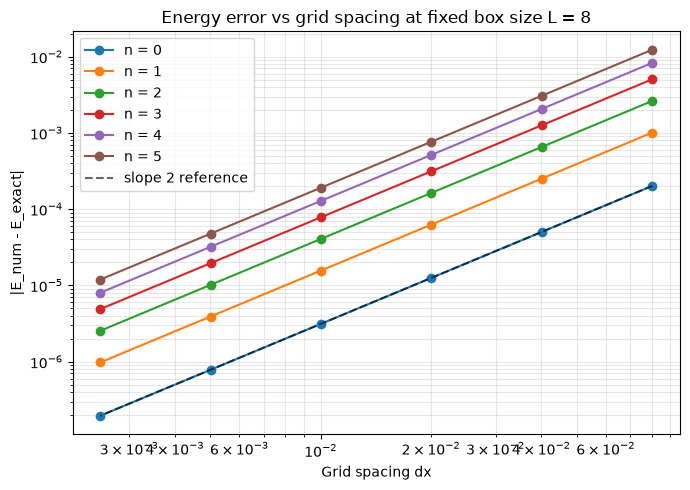

In [62]:
plt.figure(figsize=(7, 5))
for j in range(num_states):
    plt.loglog(dx_values, grid_errors[:, j], "o-", label=f"n = {j}")
plt.loglog(dx_values, grid_errors[0, 0] * (dx_values / dx_values[0])**2, "k--",
           alpha=0.6, label="slope 2 reference")
plt.xlabel("Grid spacing dx")
plt.ylabel("|E_num - E_exact|")
plt.title("Energy error vs grid spacing at fixed box size L = 8")
plt.grid(True, alpha=0.3, which="both")
plt.legend()
plt.tight_layout()
plt.show()

In [63]:
slopes = [np.polyfit(np.log(dx_values), np.log(grid_errors[:, j]), 1)[0] for j in range(num_states)]
convergence_order = pd.DataFrame({
    "n": n,
    "Fitted slope": slopes,
    "Error at dx = 0.0804": grid_errors[0],
    "Error at dx = 0.0025": grid_errors[-1],
    "Reduction factor": grid_errors[0] / grid_errors[-1],
})
convergence_order

,n,Fitted slope,Error at dx = 0.0804,Error at dx = 0.0025,Reduction factor
0,0,2.0000971766,0.0002020968,0.0000001954,1034.4169067784
1,1,2.0001731391,0.0010108116,0.0000009769,1034.7461523680
2,2,2.0002593189,0.0026290613,0.0000025399,1035.1208736711
3,3,2.0003510671,0.0050578333,0.0000048843,1035.5203363364
4,4,2.0004446383,0.0082981191,0.0000080103,1035.9273544052
5,5,2.0005395633,0.0123509142,0.0000119178,1036.3407017467


## Leading-order error model

The fitted slopes confirm the expected $O(\Delta x^2)$ behaviour, so the error should
be $|\Delta E_n| = C_n \Delta x^2$ for some constant depending on the state. Dividing
the measured errors by $\Delta x^2$ gives values that settle on
$\tfrac{1}{32}, \tfrac{5}{32}, \tfrac{13}{32}, \tfrac{25}{32}, \tfrac{41}{32}, \tfrac{61}{32}$,
whose numerators are $2n^2 + 2n + 1$. That suggests

$$
\Delta E_n \simeq -\frac{\Delta x^2}{32}\left(2n^2 + 2n + 1\right),
$$

with the minus sign because the finite difference understates the curvature and so
understates the kinetic energy. The table below tests this prediction, which has no
fitted parameters, against the measured errors.

In [64]:
predicted = np.outer(dx_values**2, (2 * n**2 + 2 * n + 1) / 32.0)
model_check = pd.DataFrame({"N": N_values, "dx": dx_values})
for j in range(num_states):
    model_check[f"ratio n={j}"] = grid_errors[:, j] / predicted[:, j]
model_check

,N,dx,ratio n=0,ratio n=1,ratio n=2,ratio n=3,ratio n=4,ratio n=5
0,200,0.0804020101,1.0004045208,1.0007287278,1.0010909128,1.0014762817,1.0018713885,1.0022716285
1,400,0.0401002506,1.0001005307,1.0001809942,1.0002707758,1.0003661727,1.0004638376,1.0005626238
2,800,0.0200250313,1.0000250647,1.0000451224,1.0000674887,1.0000912490,1.0001155668,1.0001401543
3,1600,0.0100062539,1.0000062525,1.0000112943,1.0000168505,1.0000227865,1.0000288513,1.0000349846
4,3200,0.0050015630,1.0000016426,1.0000027126,1.0000040412,1.0000058481,1.0000072125,1.0000087187
5,6400,0.0025003907,0.9999956320,1.0000014150,1.0000011979,1.0000002381,1.0000017053,1.0000021856


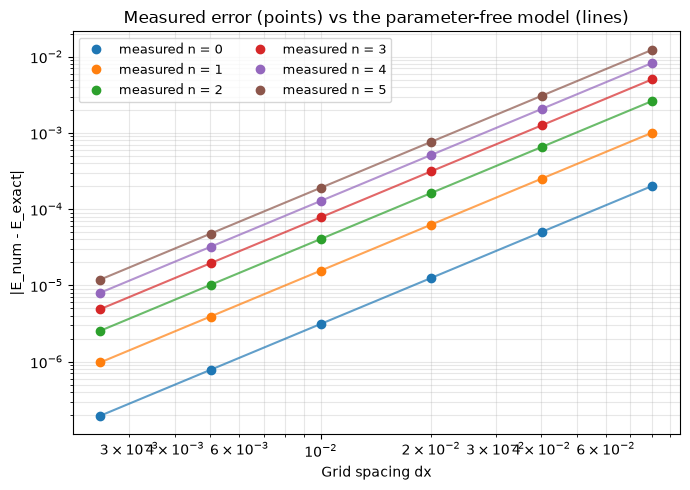

In [65]:
plt.figure(figsize=(7, 5))
for j in range(num_states):
    plt.loglog(dx_values, grid_errors[:, j], "o", label=f"measured n = {j}")
plt.gca().set_prop_cycle(None)
for j in range(num_states):
    plt.loglog(dx_values, predicted[:, j], "-", alpha=0.7)
plt.xlabel("Grid spacing dx")
plt.ylabel("|E_num - E_exact|")
plt.title("Measured error (points) vs the parameter-free model (lines)")
plt.grid(True, alpha=0.3, which="both")
plt.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

## Matrix size, solver settings, and runtime

The same Hamiltonians are now solved with four different configurations:

| Label | Call | Notes |
| --- | --- | --- |
| `eigsh SA` | `eigsh(H, k=6, which="SA")` | Lanczos on the sparse matrix, lowest algebraic eigenvalues |
| `eigsh shift-invert` | `eigsh(H, k=6, sigma=0.0, which="LM")` | Lanczos on $(H - \sigma I)^{-1}$, which clusters the wanted states at the top of the transformed spectrum |
| `eigh_tridiagonal` | `eigh_tridiagonal(d, e, select="i", select_range=(0, 5))` | direct LAPACK solver for the tridiagonal form |
| `dense eigh` | `np.linalg.eigh(H.toarray())` | full spectrum of the dense matrix, run only up to $M \approx 2000$ |

Each timing is the best of a few repeats. Memory columns compare the stored sparse
entries with the $M^2$ doubles a dense copy would require.

In [67]:
def best_time(call, repeats=3):
    times = []
    for _ in range(repeats):
        start = time.perf_counter()
        call()
        times.append(time.perf_counter() - start)
    return min(times)


timing_rows = []
for N in N_values:
    x, dx, M, H = build_hamiltonian(L, N)
    H_csc = H.tocsc()
    diag_ref = hbar**2 / (mass * dx**2) + 0.5 * mass * omega**2 * x**2
    offdiag_ref = -0.5 * (hbar**2 / mass) * np.ones(M - 1) / dx**2
    repeats = 3 if M <= 3200 else 1
    t_sa = best_time(lambda: eigsh(H, k=num_states, which="SA"), repeats)
    t_si = best_time(lambda: eigsh(H_csc, k=num_states, sigma=0.0, which="LM"), 3)
    t_tri = best_time(lambda: eigh_tridiagonal(diag_ref, offdiag_ref, eigvals_only=True,
                                               select="i", select_range=(0, num_states - 1)), 3)
    if M <= 2000:
        H_dense = H.toarray()
        t_dense = best_time(lambda: np.linalg.eigh(H_dense), 2)
    else:
        t_dense = np.nan
    sparse_mb = (H.data.nbytes + H.indices.nbytes + H.indptr.nbytes) / 1e6
    timing_rows.append({"N": N, "M": M, "nnz": H.nnz, "Sparse MB": sparse_mb,
                        "Dense MB": M * M * 8 / 1e6, "eigsh SA (s)": t_sa,
                        "eigsh shift-invert (s)": t_si, "eigh_tridiagonal (s)": t_tri,
                        "dense eigh (s)": t_dense})

cost = pd.DataFrame(timing_rows)
pd.set_option("display.precision", 5)
cost

,N,M,nnz,Sparse MB,Dense MB,eigsh SA (s),eigsh shift-invert (s),eigh_tridiagonal (s),dense eigh (s)
0,200,198,592,0.0079,0.31363,0.00755,0.00123,0.00058,0.00238
1,400,398,1192,0.0159,1.26723,0.01261,0.00111,0.00076,0.00919
2,800,798,2392,0.0319,5.09443,0.04036,0.00167,0.00146,0.04402
3,1600,1598,4792,0.0639,20.42883,0.21745,0.00249,0.00285,0.25704
4,3200,3198,9592,0.1279,81.81763,1.31266,0.00414,0.00544,NaN
5,6400,6398,19192,0.2559,327.47523,6.38502,0.00626,0.01045,NaN


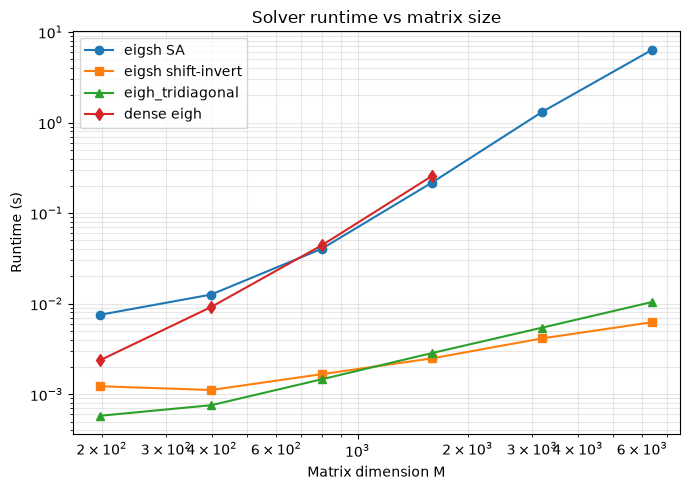

In [68]:
plt.figure(figsize=(7, 5))
M_values = cost["M"].to_numpy()
for column, marker in [("eigsh SA (s)", "o-"), ("eigsh shift-invert (s)", "s-"),
                       ("eigh_tridiagonal (s)", "^-"), ("dense eigh (s)", "d-")]:
    plt.loglog(M_values, cost[column], marker, label=column.replace(" (s)", ""))
plt.xlabel("Matrix dimension M")
plt.ylabel("Runtime (s)")
plt.title("Solver runtime vs matrix size")
plt.grid(True, alpha=0.3, which="both")
plt.legend()
plt.tight_layout()
plt.show()

In [69]:
scaling = pd.DataFrame({
    "Solver": ["eigsh SA", "eigsh shift-invert", "eigh_tridiagonal", "dense eigh"],
    "Fitted exponent p in t ~ M^p": [
        np.polyfit(np.log(M_values), np.log(cost["eigsh SA (s)"]), 1)[0],
        np.polyfit(np.log(M_values), np.log(cost["eigsh shift-invert (s)"]), 1)[0],
        np.polyfit(np.log(M_values), np.log(cost["eigh_tridiagonal (s)"]), 1)[0],
        np.polyfit(np.log(M_values[:4]), np.log(cost["dense eigh (s)"][:4]), 1)[0],
    ],
})
scaling

,Solver,Fitted exponent p in t ~ M^p
0,eigsh SA,2.02735
1,eigsh shift-invert,0.51321
2,eigh_tridiagonal,0.86545
3,dense eigh,2.24305


In [70]:
x_ref, dx_ref, M_ref, H_ref = build_hamiltonian(L, 3200)
energies_sa = np.sort(eigsh(H_ref, k=num_states, which="SA")[0])
energies_si = np.sort(eigsh(H_ref.tocsc(), k=num_states, sigma=0.0, which="LM")[0])
diag_ref = hbar**2 / (mass * dx_ref**2) + 0.5 * mass * omega**2 * x_ref**2
offdiag_ref = -0.5 * (hbar**2 / mass) * np.ones(M_ref - 1) / dx_ref**2
energies_tri = eigh_tridiagonal(diag_ref, offdiag_ref, eigvals_only=True,
                                select="i", select_range=(0, num_states - 1))
print(f"SA vs shift-invert: {np.abs(energies_sa - energies_si).max():.3e}")
print(f"SA vs eigh_tridiagonal: {np.abs(energies_sa - energies_tri).max():.3e}")
assert np.abs(energies_sa - energies_si).max() < 1e-9
assert np.abs(energies_sa - energies_tri).max() < 1e-9
print("All three solvers agree to well within the discretization error.")

SA vs shift-invert: 1.260e-12
SA vs eigh_tridiagonal: 4.474e-12
All three solvers agree to well within the discretization error.


## Results

**Convergence.** With the box fixed at $L = 8$, the fitted slopes of $\log|\Delta E_n|$
against $\log \Delta x$ are 2.00 for every state, and shrinking $\Delta x$ by a factor
of 32 shrinks the error by roughly $32^2 \approx 1000$. This is the expected
second-order behaviour of the centered difference, measured rather than assumed.

**Error model.** The measured errors match
$|\Delta E_n| = \tfrac{\Delta x^2}{32}(2n^2 + 2n + 1)$ to within a fraction of a
percent at the finer grids, with the agreement improving as $\Delta x$ shrinks and the
neglected higher-order terms die away. The error grows quadratically with the state
index, so the highest state requested sets the grid requirement.

**Cost.** The sparse storage stays negligible while a dense copy grows quadratically:
at $M \approx 6400$ the matrix holds about 19 000 nonzeros, roughly 0.26 MB, against
about 328 MB dense. Runtime tells a more interesting story than the memory does.
`eigsh` with `which="SA"` is the slowest option at large $M$, because the low-lying
eigenvalues of this operator are tightly clustered relative to the spectral range and
plain Lanczos converges slowly there. Both `sigma=0.0` shift-invert and the direct
`eigh_tridiagonal` are orders of magnitude faster at the same accuracy, and all three
agree on the eigenvalues. The fitted exponents are empirical over this range of $M$ rather than asymptotic values: at these sizes the fast solvers are partly dominated by call overhead, and the dense routine has not yet reached its eventual $O(M^3)$ regime.

**Consequence for the solver choice.** The sparse-solver argument still holds against
the dense route, but the specific setting matters: for this 1D tridiagonal Hamiltonian
`which="SA"` is the wrong knob, and either shift-invert or the tridiagonal solver
should be preferred at fine grids. This is worth carrying back into the main notebook,
where the current runs use `which="SA"`.

# Anderson Mao: Numerical Box-Size Convergence (switch pages)

# Lizzie: Plots of Harmonic Oscillator Potential, First Few Wavefunctions, and Probability Density 

This section covers the graphs of the harmonic oscillator potential, wavefunctions, and probablity density of the selected intervals and eigenstates. The codes can graph for any eigenstates inputted. All conventions match the 1D model.

## The harmonic oscillator potential
Using the known potential term, we can construct the harmonic oscillator potential:
$$V(x) = \frac{1}{2} m \omega^2 x^2$$
across the spatial interval:
$x \in [-L, L]$.

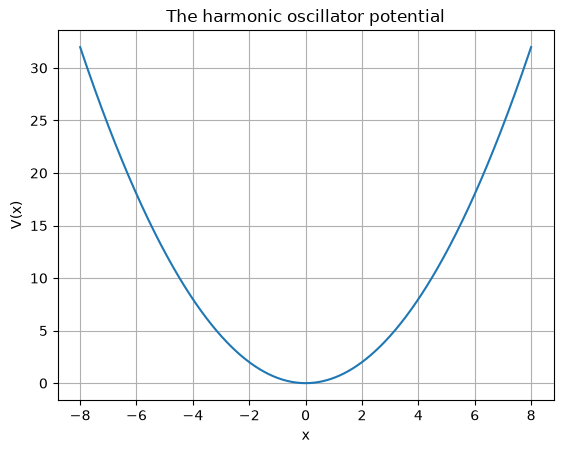

In [90]:
def potential():
    ## harmonic oscillator potential equation
    v = 0.5 * mass * omega**2 * x**2
    plt.plot(x, v)
    plt.xlabel('x')
    plt.ylabel('V(x)')
    plt.title('The harmonic oscillator potential')
    plt.grid(True)
    plt.show()

potential()

## First few wavefunctions
Using the known wavefunctions corresponding to the energies above:
$$ \psi_{n} = N_{n} e^\frac{- \alpha}{2 \hbar} H_{n} \sqrt{\alpha} x $$
where $ \alpha = \frac{m \omega}{\hbar} $.
<br>
We can graph predictions of the wavefunctions for the numerical states.
<br>
The normalization constant $$ N_{n} = \frac{1}{\sqrt{2^n n!}} \left(\frac{\alpha}{\pi}\right)^{\frac{1}{4}} $$
and using `special.hermite()` for the hermite polynomial $ H_{n} $ or each numerical state.

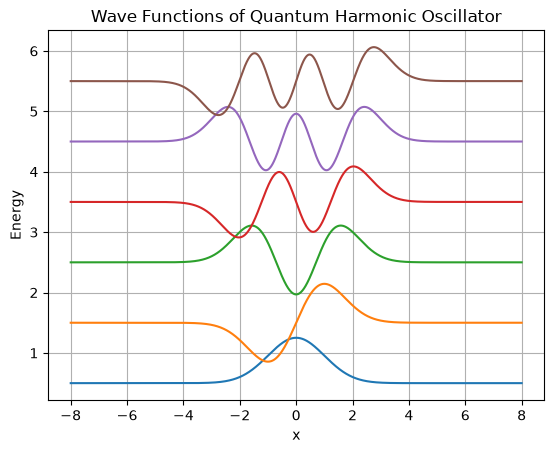

In [92]:
def psi(num_states, x):
    alpha = mass * omega / hbar
    ## normalization constant
    N = 1 / np.sqrt(2**n * factorial(n)) * (alpha / np.pi)**(0.25)
    ## Hermite polynomial
    H = special.hermite(n)
    ## wavefunctions that correspond to these energies
    return N * np.exp(-alpha * x**2 / 2) * H(np.sqrt(alpha) * x)

## same first 6 wavefunctions
for n in range(num_states):
    ## analytical energies
    plt.plot(x, psi(num_states, x) + n + 0.5)

plt.title('Wave Functions of Quantum Harmonic Oscillator')
plt.xlabel('x')
plt.ylabel('Energy')
plt.grid(True)
plt.show()

## Probablity Density
The probabilty density of the quantum harmonic oscillator is $$ |\psi_{n}|^2 $$
Using the wavefunctions found above, we are able to graph the probablity density of a chosen energy level.

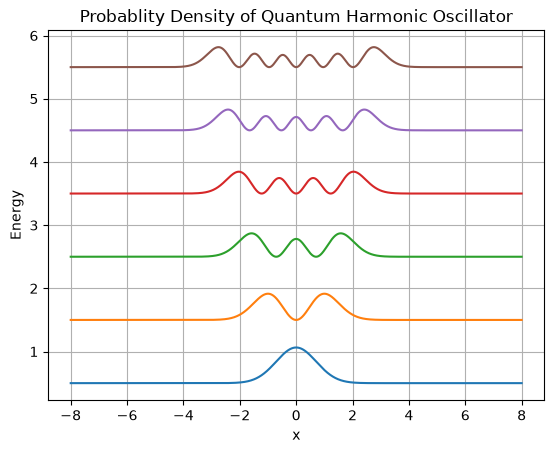

In [85]:
for n in range(num_states):
    plt.plot(x, abs(psi(num_states, x))**2 + n + 0.5)
plt.title('Probablity Density of Quantum Harmonic Oscillator')
plt.xlabel('x')
plt.ylabel('Energy')
plt.grid(True)
plt.show()